## Linear Regression – Boston Housing Dataset (Data Analytics I)

### Problem Statement

The objective is to build a Linear Regression model using Python to predict house prices using the Boston Housing dataset.
The dataset contains 506 samples and 14 features describing different aspects of houses in Boston.
The goal is to train a model that can predict the median house price (MEDV) based on these features.

## Import Required Libraries

In [30]:
# import Libraries
# !pip install scikit-learn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression

## Load dataset into dataframe

In [31]:
df = pd.read_csv('BostonHousing.csv')

## Display dataset

In [32]:
df.head()

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [33]:
df.tail()

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


## Data Preprocessing

In [34]:
df.columns

Index(['Crime_rate', 'zn', 'indus', 'chas', 'nox', 'rm', 'Age', 'Distance',
       'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv'],
      dtype='str')

In [35]:
df.dtypes

Crime_rate    float64
zn            float64
indus         float64
chas            int64
nox           float64
rm            float64
Age           float64
Distance      float64
rad             int64
tax             int64
ptratio       float64
b             float64
lstat         float64
medv          float64
dtype: object

In [36]:
df.dropna()

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [38]:
df['rm']=df['rm'].fillna(df['rm'].mean())

In [39]:
df.isnull().sum()

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            0
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

## Seperate Input Output data

In [40]:
# x = input data (House feacture)
x = df.drop('medv',axis =1)
x.head()

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [41]:
# y = output data (House Price)
y= df['medv']
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: medv, dtype: float64

## Split dataset into the Training and Testing

In [42]:
# Split data into training and testing sets
# 80% training, 20% testing
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)

## Train Model

In [43]:
# Create Linear Regression model
model = LinearRegression()

# Train model using training data
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Make Predictions

In [46]:
# Predict house prices
y_pred = model.predict(x_test)

print("Predictions completed.")

Predictions completed.


## Compare Actual vs Predicted

In [56]:
print('Actual Price ---> Predicted Price')

for actual, predicted in zip(y_test, y_pred):
    print(actual, '--->', predicted)

comparison = pd.DataFrame({
    'Actual Price':y_test.values,
    'Predicted Values ':y_pred
})
comparison.head()

Actual Price ---> Predicted Price
23.6 ---> 28.981418724969174
32.4 ---> 36.01423173175603
13.6 ---> 14.824309193106444
22.8 ---> 25.022935704551273
16.1 ---> 18.77077366034586
20.0 ---> 23.25088901014903
17.8 ---> 17.659213548938748
14.0 ---> 14.331215697703508
19.6 ---> 23.017995975221304
16.8 ---> 20.619237250341378
21.5 ---> 24.9147754224147
18.9 ---> 18.65745018728564
7.0 ---> -6.080248718554948
21.2 ---> 21.75669433758091
18.5 ---> 19.236084363121268
29.8 ---> 26.184836375302506
18.8 ---> 20.655217852720497
10.2 ---> 5.800892057311501
50.0 ---> 40.48814090945295
14.1 ---> 17.615197608507955
25.2 ---> 27.233325545269278
29.1 ---> 30.0531719113306
12.7 ---> 11.33286739734968
22.4 ---> 24.138369296815267
14.2 ---> 17.86296593742377
13.8 ---> 15.84437533281645
20.3 ---> 22.778432764284698
14.9 ---> 14.575211472088275
21.7 ---> 22.436674700644815
18.3 ---> 19.185993156703763
23.1 ---> 22.424929409909485
23.8 ---> 25.206385267215882
15.0 ---> 25.926331410714372
20.8 ---> 17.71447189605

,Actual Price,Predicted Values
0,23.6,28.981419
1,32.4,36.014232
2,13.6,14.824309
3,22.8,25.022936
4,16.1,18.770774


<Axes: xlabel='medv'>

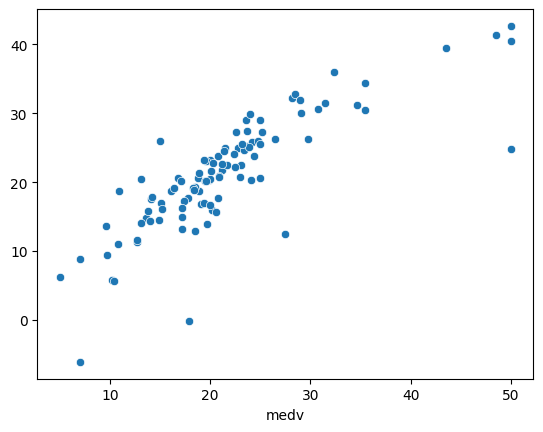

In [61]:
import seaborn as sns
sns.scatterplot(x = y_test, y = y_pred)

## Model Evaluation

In [68]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

# R2 Score (main performance metric)
r2 = r2_score(y_test, y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print("\nModel Performance:")
print("R2 Score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)


Model Performance:
R2 Score: 0.6672089705941868
Mean Squared Error: 24.40482518814656
Mean Absolute Error: 3.2064039639003954
